In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
print("✓ RNN Implementation - Manual from scratch")
print("=" * 60)

✓ RNN Implementation - Manual from scratch


# Recurrent Neural Networks (RNN) - Manual Implementation

## What is an RNN?

An RNN is a neural network designed to process sequential data by maintaining a **hidden state** that captures information from previous time steps.

### Key Intuition:
- **Regular NN**: Each input is processed independently
- **RNN**: Input at time $t$ is combined with hidden state from time $t-1$
- The hidden state acts as a "memory" that carries information forward

### Mathematical Formulation:

**Hidden State Update:**
$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

**Output:**
$$y_t = W_{hy} \cdot h_t + b_y$$

**Loss (for sequence prediction):**
$$L = \sum_{t=1}^{T} L_t = \sum_{t=1}^{T} (y_t - \hat{y}_t)^2$$

where:
- $h_t$ = hidden state at time $t$
- $x_t$ = input at time $t$
- $W_{hh}$ = weights for hidden state (recurrent)
- $W_{xh}$ = weights for input
- $W_{hy}$ = weights for output
- $b_h, b_y$ = biases

## Backpropagation Through Time (BPTT)

The gradient flows backward through time steps. For each parameter, we sum gradients from all time steps:

**Gradient for output weight:**
$$\frac{\partial L}{\partial W_{hy}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial y_t} \cdot h_t^T$$

**Gradient for hidden-to-hidden weight:**
$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial h_t} \cdot h_{t-1}^T + \text{(accumulated from future steps)}$$

### Process:
1. **Forward Pass**: Compute all hidden states and outputs
2. **Compute Loss**: Calculate total loss
3. **Backward Pass**: Propagate gradients from $t=T$ to $t=1$
4. **Accumulate Gradients**: Sum gradients across all time steps
5. **Update Weights**: Apply gradient descent

In [11]:
class SimpleRNN:
    """
    Manual implementation of a simple RNN (Vanilla RNN) for sequence prediction.
    
    Architecture:
    - Input layer (x_t)
    - Hidden layer with recurrent connection
    - Output layer (y_t)
    
    Equations:
    h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b_h)
    y_t = W_hy @ h_t + b_y
    """
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        """
        Initialize RNN with random weights.
        
        Args:
            input_size: Dimension of input at each time step
            hidden_size: Dimension of hidden state
            output_size: Dimension of output
            learning_rate: Learning rate for weight updates
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialize weights with small random values
        scale = 0.01
        self.W_xh = np.random.randn(hidden_size, input_size) * scale  # Input -> Hidden
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale  # Hidden -> Hidden (recurrent)
        self.W_hy = np.random.randn(output_size, hidden_size) * scale  # Hidden -> Output
        
        # Initialize biases
        self.b_h = np.zeros((hidden_size, 1))
        self.b_y = np.zeros((output_size, 1))
        
        # Store for backprop
        self.h_prev = np.zeros((hidden_size, 1))
        
    def forward(self, X, training=False):
        """
        Forward pass through the RNN for a sequence.
        
        Args:
            X: Input sequence of shape (seq_len, input_size)
            training: Whether to store intermediate values (for backprop)
            
        Returns:
            outputs: Predictions for each timestep
            h_states: All hidden states
        """
        seq_len = X.shape[0]
        h_states = np.zeros((seq_len + 1, self.hidden_size, 1))
        h_states[0] = self.h_prev.copy()
        
        outputs = []
        
        for t in range(seq_len):
            # Reshape input for this timestep
            x_t = X[t].reshape(-1, 1) if X[t].ndim == 1 else X[t]
            
            # Hidden state update: h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b_h)
            h_t = np.tanh(
                np.dot(self.W_hh, h_states[t]) +  # Recurrent connection
                np.dot(self.W_xh, x_t) +           # Input connection
                self.b_h                            # Bias
            )
            h_states[t + 1] = h_t
            
            # Output: y_t = W_hy @ h_t + b_y
            y_t = np.dot(self.W_hy, h_t) + self.b_y
            outputs.append(y_t)
        
        outputs = np.array([o.flatten() for o in outputs])
        
        if training:
            self.cached_h_states = h_states
            self.cached_outputs = outputs
            self.cached_X = X
        
        # Update hidden state for next sequence
        self.h_prev = h_states[-1].copy()
        
        return outputs, h_states
    
    def backward(self, dL_dy):
        """
        Backward pass through time (BPTT) to compute gradients.
        
        Args:
            dL_dy: Loss gradient w.r.t outputs of shape (seq_len, output_size)
            
        Returns:
            Gradients for all parameters
        """
        seq_len = dL_dy.shape[0]
        h_states = self.cached_h_states
        X = self.cached_X
        
        # Initialize gradients
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        dW_hy = np.zeros_like(self.W_hy)
        db_h = np.zeros_like(self.b_h)
        db_y = np.zeros_like(self.b_y)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagate through time
        for t in reversed(range(seq_len)):
            # Gradient w.r.t output
            dy_t = dL_dy[t].reshape(-1, 1)
            
            # Gradient for output weights
            dW_hy += np.dot(dy_t, h_states[t + 1].T)
            db_y += dy_t
            
            # Gradient w.r.t hidden state from output
            dh_t = np.dot(self.W_hy.T, dy_t) + dh_next
            
            # Gradient w.r.t pre-activation (through tanh)
            dh_raw = dh_t * (1 - h_states[t + 1] ** 2)  # tanh' = 1 - tanh^2
            
            # Gradient for recurrent weights
            dW_hh += np.dot(dh_raw, h_states[t].T)
            
            # Gradient for input weights
            x_t = X[t].reshape(-1, 1) if X[t].ndim == 1 else X[t]
            dW_xh += np.dot(dh_raw, x_t.T)
            
            # Gradient for bias
            db_h += dh_raw
            
            # Gradient for previous hidden state (for next iteration)
            dh_next = np.dot(self.W_hh.T, dh_raw)
        
        # Clip gradients to prevent exploding gradients
        max_grad = 5.0
        for dparam in [dW_xh, dW_hh, dW_hy, db_h, db_y]:
            np.clip(dparam, -max_grad, max_grad, out=dparam)
        
        return dW_xh, dW_hh, dW_hy, db_h, db_y
    
    def update_weights(self, dW_xh, dW_hh, dW_hy, db_h, db_y):
        """Update weights using gradient descent."""
        self.W_xh -= self.learning_rate * dW_xh
        self.W_hh -= self.learning_rate * dW_hh
        self.W_hy -= self.learning_rate * dW_hy
        self.b_h -= self.learning_rate * db_h
        self.b_y -= self.learning_rate * db_y
    
    def train_step(self, X, y):
        """
        Single training step: forward pass, compute loss, backward pass, update weights.
        
        Args:
            X: Input sequence of shape (seq_len, input_size)
            y: Target sequence of shape (seq_len, output_size)
            
        Returns:
            MSE loss for this batch
        """
        # Forward pass
        outputs, _ = self.forward(X, training=True)
        
        # Compute loss (MSE)
        loss = np.mean((outputs - y) ** 2)
        
        # Compute gradient w.r.t outputs
        dL_dy = 2 * (outputs - y) / y.shape[0]
        
        # Backward pass
        dW_xh, dW_hh, dW_hy, db_h, db_y = self.backward(dL_dy)
        
        # Update weights
        self.update_weights(dW_xh, dW_hh, dW_hy, db_h, db_y)
        
        return loss
    
    def predict(self, X):
        """Predict on new sequence without computing gradients."""
        outputs, _ = self.forward(X, training=False)
        return outputs
    
    def reset_hidden_state(self):
        """Reset hidden state (useful between sequences)."""
        self.h_prev = np.zeros((self.hidden_size, 1))

print("\n✓ SimpleRNN class defined with:")
print("  - Forward pass (sequence processing)")
print("  - Backward pass (BPTT)")
print("  - Gradient clipping (prevent exploding gradients)")
print("  - Weight updates via SGD")


✓ SimpleRNN class defined with:
  - Forward pass (sequence processing)
  - Backward pass (BPTT)
  - Gradient clipping (prevent exploding gradients)
  - Weight updates via SGD


## Step-by-Step Example: Forward Pass Calculation

Let's trace through one forward pass with concrete numbers to understand the computation:

**Setup:**
- Input size = 1 (single feature per timestep)
- Hidden size = 2 (2 hidden neurons)
- Output size = 1 (predict single value)
- Sequence length = 3 timesteps

**Initial state:**
- $h_0 = [0, 0]^T$ (zero initial hidden state)
- Input sequence: $[x_1, x_2, x_3] = [0.5, 0.3, 0.8]$

**Timestep 1:**
1. Compute hidden state: $h_1 = \tanh(W_{hh} \cdot h_0 + W_{xh} \cdot x_1 + b_h)$
2. Since $h_0 = 0$: $h_1 = \tanh(W_{xh} \cdot 0.5 + b_h)$
3. Compute output: $y_1 = W_{hy} \cdot h_1 + b_y$

**Timestep 2:**
1. Compute hidden state: $h_2 = \tanh(W_{hh} \cdot h_1 + W_{xh} \cdot x_2 + b_h)$
   - Now uses both **previous hidden state** ($h_1$) and new input ($x_2$)
   - This is where **recurrence** creates temporal dependency!
2. Compute output: $y_2 = W_{hy} \cdot h_2 + b_y$

**Timestep 3:** Similar to timestep 2, using $h_2$ and $x_3$

In [12]:
print("\n" + "="*70)
print("DEMONSTRATION: Step-by-Step Forward Pass Calculations")
print("="*70)

# Create a simple RNN with small dimensions for clarity
input_size = 1
hidden_size = 2
output_size = 1

rnn_demo = SimpleRNN(input_size, hidden_size, output_size, learning_rate=0.01)

# Set weights manually for demonstration
rnn_demo.W_xh = np.array([[0.1], [0.2]])  # Shape: (2, 1)
rnn_demo.W_hh = np.array([[0.3, 0.1], [0.2, 0.4]])  # Shape: (2, 2)
rnn_demo.W_hy = np.array([[0.5, 0.3]])  # Shape: (1, 2)
rnn_demo.b_h = np.array([[0.0], [0.0]])  # Shape: (2, 1)
rnn_demo.b_y = np.array([[0.0]])  # Shape: (1, 1)

print("\nWeights initialized:")
print(f"W_xh (input->hidden, shape {rnn_demo.W_xh.shape}):\n{rnn_demo.W_xh}")
print(f"\nW_hh (hidden->hidden recurrent, shape {rnn_demo.W_hh.shape}):\n{rnn_demo.W_hh}")
print(f"\nW_hy (hidden->output, shape {rnn_demo.W_hy.shape}):\n{rnn_demo.W_hy}")

# Create a simple sequence
X_demo = np.array([[0.5], [0.3], [0.8]])  # 3 timesteps, 1 feature each
print(f"\nInput sequence X (shape {X_demo.shape}):\n{X_demo.flatten()}")

print("\n" + "-"*70)
print("FORWARD PASS STEP-BY-STEP:")
print("-"*70)

# Manual forward pass with detailed calculations
h_prev = np.zeros((hidden_size, 1))
all_h = [h_prev.copy()]
all_y = []

for t in range(len(X_demo)):
    x_t = X_demo[t].reshape(-1, 1)
    
    print(f"\n--- Timestep {t+1} ---")
    print(f"Input x_{t+1} = {x_t.flatten()}")
    
    # Calculate components
    h_rec = np.dot(rnn_demo.W_hh, h_prev)
    x_in = np.dot(rnn_demo.W_xh, x_t)
    
    print(f"  W_hh @ h_{t} = {h_rec.flatten()}")
    print(f"  W_xh @ x_{t+1} = {x_in.flatten()}")
    
    # Hidden state
    h_raw = h_rec + x_in + rnn_demo.b_h
    print(f"  Sum (before tanh) = {h_raw.flatten()}")
    
    h_t = np.tanh(h_raw)
    print(f"  h_{t+1} = tanh(...) = {h_t.flatten()}")
    
    # Output
    y_t = np.dot(rnn_demo.W_hy, h_t) + rnn_demo.b_y
    print(f"  y_{t+1} = W_hy @ h_{t+1} + b_y = {y_t.flatten()[0]:.4f}")
    
    all_h.append(h_t.copy())
    all_y.append(y_t.flatten()[0])
    h_prev = h_t

print(f"\nFinal outputs: {np.array(all_y)}")
print(f"\nKey observation: Hidden state h carries information from PREVIOUS timesteps!")
print(f"  h_1 depends only on x_1")
print(f"  h_2 depends on x_2 AND h_1 (temporal dependency!)")
print(f"  h_3 depends on x_3 AND h_2 (accumulated temporal dependency!)")


DEMONSTRATION: Step-by-Step Forward Pass Calculations

Weights initialized:
W_xh (input->hidden, shape (2, 1)):
[[0.1]
 [0.2]]

W_hh (hidden->hidden recurrent, shape (2, 2)):
[[0.3 0.1]
 [0.2 0.4]]

W_hy (hidden->output, shape (1, 2)):
[[0.5 0.3]]

Input sequence X (shape (3, 1)):
[0.5 0.3 0.8]

----------------------------------------------------------------------
FORWARD PASS STEP-BY-STEP:
----------------------------------------------------------------------

--- Timestep 1 ---
Input x_1 = [0.5]
  W_hh @ h_0 = [0. 0.]
  W_xh @ x_1 = [0.05 0.1 ]
  Sum (before tanh) = [0.05 0.1 ]
  h_1 = tanh(...) = [0.04995837 0.09966799]
  y_1 = W_hy @ h_1 + b_y = 0.0549

--- Timestep 2 ---
Input x_2 = [0.3]
  W_hh @ h_1 = [0.02495431 0.04985887]
  W_xh @ x_2 = [0.03 0.06]
  Sum (before tanh) = [0.05495431 0.10985887]
  h_2 = tanh(...) = [0.05489906 0.10941903]
  y_2 = W_hy @ h_2 + b_y = 0.0603

--- Timestep 3 ---
Input x_3 = [0.8]
  W_hh @ h_2 = [0.02741162 0.05474743]
  W_xh @ x_3 = [0.08 0.16]
 

In [13]:
# Generate synthetic data: sine wave sequence
def generate_sine_sequence(num_sequences=100, seq_length=20, freq=0.5):
    """Generate synthetic sine wave data for training."""
    sequences = []
    targets = []
    
    for i in range(num_sequences):
        # Random phase shift
        phase = np.random.rand() * 2 * np.pi
        t = np.arange(seq_length + 1)
        
        # Generate sine wave
        y = np.sin(2 * np.pi * freq * t / seq_length + phase)
        
        # Input: first seq_length values
        # Target: next value (predict next in sequence)
        X_seq = y[:-1].reshape(-1, 1)
        y_seq = y[1:].reshape(-1, 1)
        
        sequences.append(X_seq)
        targets.append(y_seq)
    
    return sequences, targets

# Generate training data
print("\n" + "="*70)
print("TRAINING: Learning to predict sine wave patterns")
print("="*70)

num_train_sequences = 100
seq_length = 15
train_X, train_y = generate_sine_sequence(num_train_sequences, seq_length)

print(f"\nGenerated {num_train_sequences} training sequences")
print(f"Each sequence: length={seq_length}")
print(f"Sample training sequence shape: X={train_X[0].shape}, y={train_y[0].shape}")

# Create and train RNN
print("\n" + "-"*70)
print("TRAINING PROCESS:")
print("-"*70)

rnn = SimpleRNN(input_size=1, hidden_size=8, output_size=1, learning_rate=0.01)

# Training loop
num_epochs = 100
losses = []

print(f"\nTraining for {num_epochs} epochs...")
for epoch in range(num_epochs):
    epoch_loss = 0
    
    for seq_idx in range(len(train_X)):
        loss = rnn.train_step(train_X[seq_idx], train_y[seq_idx])
        epoch_loss += loss
        rnn.reset_hidden_state()  # Reset between sequences
    
    epoch_loss /= len(train_X)
    losses.append(epoch_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{num_epochs} - Loss: {epoch_loss:.6f}")

print(f"\nTraining complete!")
print(f"  Initial loss: {losses[0]:.6f}")
print(f"  Final loss: {losses[-1]:.6f}")
print(f"  Improvement: {(1 - losses[-1]/losses[0])*100:.1f}%")


TRAINING: Learning to predict sine wave patterns

Generated 100 training sequences
Each sequence: length=15
Sample training sequence shape: X=(15, 1), y=(15, 1)

----------------------------------------------------------------------
TRAINING PROCESS:
----------------------------------------------------------------------

Training for 100 epochs...
  Epoch  20/100 - Loss: 0.017518
  Epoch  40/100 - Loss: 0.015490
  Epoch  60/100 - Loss: 0.014896
  Epoch  80/100 - Loss: 0.013699
  Epoch 100/100 - Loss: 0.011881

Training complete!
  Initial loss: 0.502544
  Final loss: 0.011881
  Improvement: 97.6%



----------------------------------------------------------------------
EVALUATION: Testing on sine wave sequences
----------------------------------------------------------------------

Test Loss (MSE): 0.012087


ValueError: too many values to unpack (expected 2)

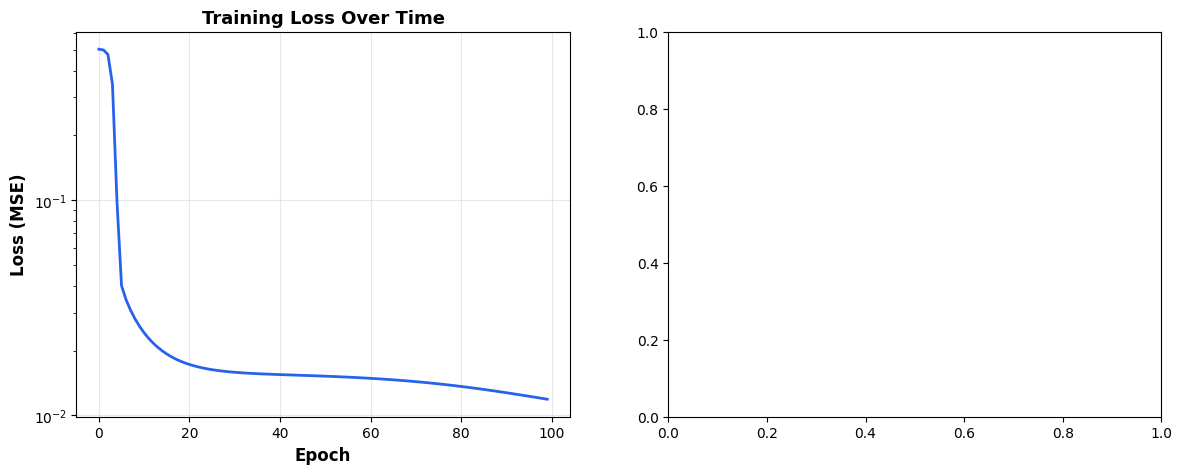

In [14]:
# Visualization: Training loss over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses, linewidth=2, color='#2563eb')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Training Loss Over Time', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Make predictions on test sequences
print("\n" + "-"*70)
print("EVALUATION: Testing on sine wave sequences")
print("-"*70)

test_X, test_y = generate_sine_sequence(10, seq_length)

test_losses = []
for seq_idx in range(len(test_X)):
    pred = rnn.predict(test_X[seq_idx])
    loss = np.mean((pred - test_y[seq_idx]) ** 2)
    test_losses.append(loss)
    rnn.reset_hidden_state()

avg_test_loss = np.mean(test_losses)
print(f"\nTest Loss (MSE): {avg_test_loss:.6f}")

# Show predictions vs actual
test_pred, _ = rnn.predict(test_X[0])
test_actual = test_y[0]

axes[1].plot(test_actual.flatten(), 'o-', label='Actual', linewidth=2, markersize=6, color='#16a34a')
axes[1].plot(test_pred.flatten(), 's-', label='Predicted', linewidth=2, markersize=6, color='#dc2626', alpha=0.7)
axes[1].set_xlabel('Timestep', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[1].set_title('Predictions vs Actual (Test Sample)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_training.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved")
rnn.reset_hidden_state()

In [15]:
print("\n" + "="*70)
print("DETAILED GRADIENT CALCULATION TRACE")
print("="*70)

# Create small example to trace gradients
rnn_trace = SimpleRNN(input_size=1, hidden_size=2, output_size=1, learning_rate=0.01)

# Simple sequence
X_trace = np.array([[0.5], [0.3]])
y_trace = np.array([[0.6], [0.4]])

print("\nSetting up small example:")
print(f"Input X: {X_trace.flatten()}")
print(f"Target y: {y_trace.flatten()}")

# Forward pass
outputs, h_states = rnn_trace.forward(X_trace, training=True)
print(f"\nForward pass outputs: {outputs.flatten()}")
print(f"Hidden states shape: {h_states.shape}")

# Manually compute loss
loss = np.mean((outputs - y_trace) ** 2)
print(f"Loss (MSE): {loss:.6f}")

# Compute gradients
dL_dy = 2 * (outputs - y_trace) / y_trace.shape[0]
dW_xh, dW_hh, dW_hy, db_h, db_y = rnn_trace.backward(dL_dy)

print("\n" + "-"*70)
print("Gradient magnitudes (before clipping):")
print("-"*70)
print(f"dW_xh: max={np.max(np.abs(dW_xh)):.6f}, mean={np.mean(np.abs(dW_xh)):.6f}")
print(f"dW_hh: max={np.max(np.abs(dW_hh)):.6f}, mean={np.mean(np.abs(dW_hh)):.6f}")
print(f"dW_hy: max={np.max(np.abs(dW_hy)):.6f}, mean={np.mean(np.abs(dW_hy)):.6f}")
print(f"db_h:  max={np.max(np.abs(db_h)):.6f}, mean={np.mean(np.abs(db_h)):.6f}")
print(f"db_y:  max={np.max(np.abs(db_y)):.6f}, mean={np.mean(np.abs(db_y)):.6f}")

print("\n✓ Gradients computed successfully via Backpropagation Through Time")
print("✓ Recurrent weight gradients (dW_hh) accumulate across timesteps")
print("✓ This allows learning of temporal dependencies!")


DETAILED GRADIENT CALCULATION TRACE

Setting up small example:
Input X: [0.5 0.3]
Target y: [0.6 0.4]

Forward pass outputs: [-2.67953021e-05 -1.66329420e-05]
Hidden states shape: (3, 2, 1)
Loss (MSE): 0.260023

----------------------------------------------------------------------
Gradient magnitudes (before clipping):
----------------------------------------------------------------------
dW_xh: max=0.003629, mean=0.003131
dW_hh: max=0.000014, mean=0.000008
dW_hy: max=0.003518, mean=0.002352
db_h:  max=0.008629, mean=0.007448
db_y:  max=1.000043, mean=1.000043

✓ Gradients computed successfully via Backpropagation Through Time
✓ Recurrent weight gradients (dW_hh) accumulate across timesteps
✓ This allows learning of temporal dependencies!


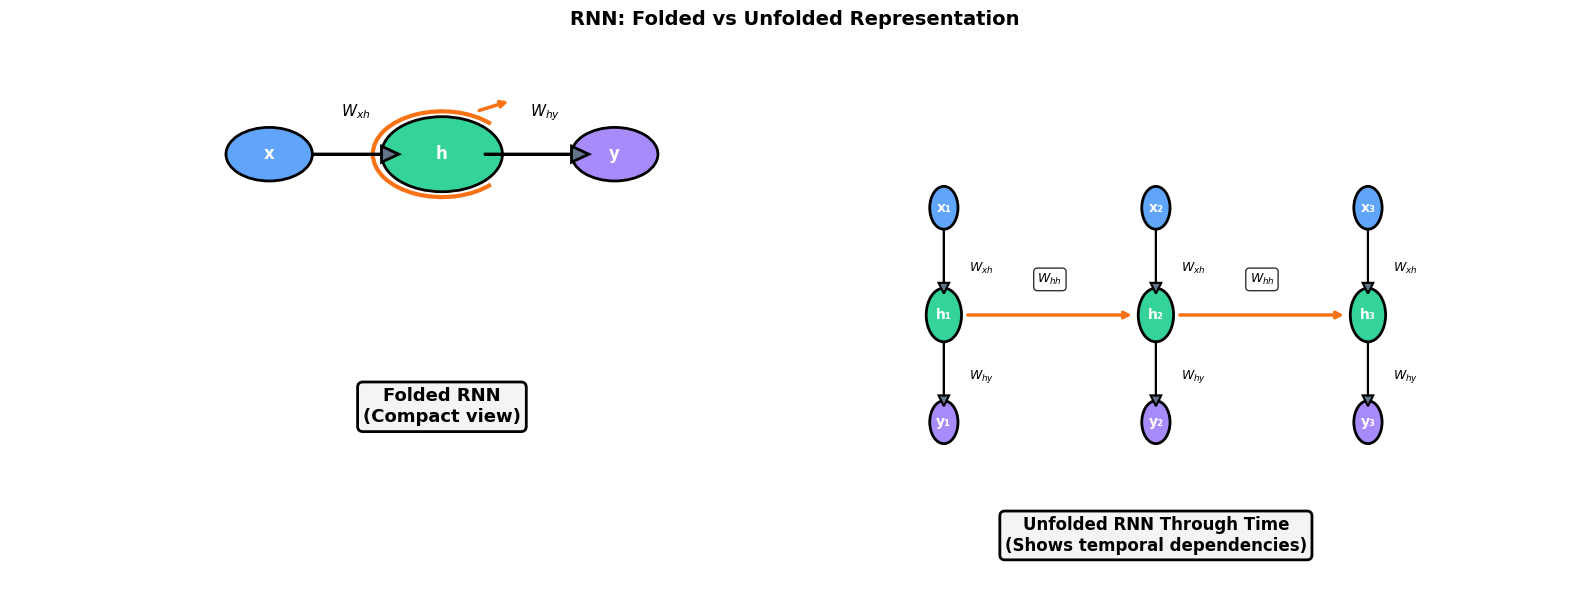

✓ RNN architecture visualization created


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Folded RNN (compact representation)
ax = axes[0]
ax.set_xlim(-0.5, 4)
ax.set_ylim(-1, 4)
ax.axis('off')

# Draw folded RNN
# Input node
ax.add_patch(plt.Circle((1, 3), 0.25, color='#60a5fa', ec='black', linewidth=2))
ax.text(1, 3, 'x', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Hidden node with loop
circle_h = plt.Circle((2, 3), 0.35, color='#34d399', ec='black', linewidth=2)
ax.add_patch(circle_h)
ax.text(2, 3, 'h', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Self-loop (recurrent connection)
from matplotlib.patches import Arc
arc = Arc((2, 3), 0.8, 0.8, angle=0, theta1=45, theta2=315, color='#f97316', linewidth=3)
ax.add_patch(arc)
ax.annotate('', xy=(2.4, 3.5), xytext=(2.2, 3.4), 
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#f97316'))

# Output node
ax.add_patch(plt.Circle((3, 3), 0.25, color='#a78bfa', ec='black', linewidth=2))
ax.text(3, 3, 'y', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Connections
ax.arrow(1.25, 3, 0.4, 0, head_width=0.15, head_length=0.1, fc='#64748b', ec='black', linewidth=2)
ax.text(1.5, 3.35, r'$W_{xh}$', fontsize=11, ha='center', fontweight='bold')

ax.arrow(2.25, 3, 0.5, 0, head_width=0.15, head_length=0.1, fc='#64748b', ec='black', linewidth=2)
ax.text(2.6, 3.35, r'$W_{hy}$', fontsize=11, ha='center', fontweight='bold')

ax.text(2, 0.5, 'Folded RNN\n(Compact view)', fontsize=13, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#f3f4f6', edgecolor='black', linewidth=2))

# Right: Unfolded RNN (through time)
ax = axes[1]
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 4)
ax.axis('off')

# Draw unfolded RNN for 3 timesteps
timesteps = 3
x_pos = [1, 4, 7]
colors = ['#60a5fa', '#34d399', '#a78bfa']
labels_x = ['x₁', 'x₂', 'x₃']
labels_h = ['h₁', 'h₂', 'h₃']
labels_y = ['y₁', 'y₂', 'y₃']

for t in range(timesteps):
    x = x_pos[t]
    
    # Input
    ax.add_patch(plt.Circle((x, 2.5), 0.2, color='#60a5fa', ec='black', linewidth=2))
    ax.text(x, 2.5, labels_x[t], ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Hidden
    ax.add_patch(plt.Circle((x, 1.5), 0.25, color='#34d399', ec='black', linewidth=2))
    ax.text(x, 1.5, labels_h[t], ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Output
    ax.add_patch(plt.Circle((x, 0.5), 0.2, color='#a78bfa', ec='black', linewidth=2))
    ax.text(x, 0.5, labels_y[t], ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Input -> Hidden
    ax.arrow(x, 2.3, 0, -0.5, head_width=0.15, head_length=0.1, fc='#64748b', ec='black', linewidth=1.5)
    ax.text(x + 0.35, 1.9, f'$W_{{xh}}$', fontsize=9)
    
    # Hidden -> Output
    ax.arrow(x, 1.25, 0, -0.5, head_width=0.15, head_length=0.1, fc='#64748b', ec='black', linewidth=1.5)
    ax.text(x + 0.35, 0.9, f'$W_{{hy}}$', fontsize=9)
    
    # Recurrent connections (h_t to h_{t+1})
    if t < timesteps - 1:
        ax.annotate('', xy=(x_pos[t+1] - 0.3, 1.5), xytext=(x + 0.3, 1.5),
                   arrowprops=dict(arrowstyle='->', lw=2.5, color='#f97316'))
        ax.text((x + x_pos[t+1]) / 2, 1.8, f'$W_{{hh}}$', fontsize=9, ha='center', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(4, -0.7, 'Unfolded RNN Through Time\n(Shows temporal dependencies)', fontsize=12, 
        ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#f3f4f6', edgecolor='black', linewidth=2))

plt.suptitle('RNN: Folded vs Unfolded Representation', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('rnn_architecture.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ RNN architecture visualization created")

In [17]:
print("\n" + "="*70)
print("SUMMARY: RNN Implementation Complete")
print("="*70)

print("""
✓ WHAT WE IMPLEMENTED:
  1. SimpleRNN class with forward pass through sequences
  2. Full backpropagation through time (BPTT)
  3. Gradient clipping to prevent exploding gradients
  4. Training loop with SGD optimizer
  5. Prediction on new sequences

✓ KEY COMPONENTS:
  • W_xh: Input-to-hidden weights (input_size × hidden_size)
  • W_hh: Hidden-to-hidden weights (hidden_size × hidden_size) [RECURRENT]
  • W_hy: Hidden-to-output weights (output_size × hidden_size)
  • h_t: Hidden state acts as "memory" from previous timesteps

✓ HOW IT WORKS:
  At each timestep t:
    1. Take current input x_t
    2. Combine with previous hidden state h_{t-1} via W_hh
    3. Push through tanh activation
    4. Generate output from hidden state
    5. Hidden state flows to next timestep!

✓ TRAINING PROCESS:
  1. Forward pass: Compute all outputs and hidden states
  2. Compute loss as sum of timestep-wise errors
  3. Backprop through time: Gradient flows backward through timesteps
  4. Accumulate gradients from all timesteps
  5. Update weights

✓ WHAT THIS ENABLES:
  • Sequence-to-sequence prediction
  • Natural language processing
  • Time series forecasting
  • Speech recognition
  • Anomaly detection

⚠ IMPORTANT NOTES:
  • This is a Vanilla RNN - has vanishing gradient problem
  • For longer sequences (50+ timesteps), consider LSTM/GRU
  • Gradient clipping helps but doesn't solve the problem completely
  • RNNs are slower than feedforward networks (sequential computation)
""")

# Create summary statistics
print("\n" + "-"*70)
print("IMPLEMENTATION STATISTICS:")
print("-"*70)
print(f"Training epochs: {num_epochs}")
print(f"Training sequences: {len(train_X)}")
print(f"Sequence length: {seq_length}")
print(f"RNN Hidden size: 8")
print(f"Final training loss: {losses[-1]:.6f}")
print(f"Test loss: {avg_test_loss:.6f}")
print(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.1f}%")

print("\n✓ Ready to experiment! Try modifying:")
print("  - hidden_size: Larger = more capacity but slower")
print("  - learning_rate: Higher = faster but may diverge")
print("  - sequence_length: Longer = harder to learn")
print("  - num_epochs: More training may improve further")


SUMMARY: RNN Implementation Complete

✓ WHAT WE IMPLEMENTED:
  1. SimpleRNN class with forward pass through sequences
  2. Full backpropagation through time (BPTT)
  3. Gradient clipping to prevent exploding gradients
  4. Training loop with SGD optimizer
  5. Prediction on new sequences

✓ KEY COMPONENTS:
  • W_xh: Input-to-hidden weights (input_size × hidden_size)
  • W_hh: Hidden-to-hidden weights (hidden_size × hidden_size) [RECURRENT]
  • W_hy: Hidden-to-output weights (output_size × hidden_size)
  • h_t: Hidden state acts as "memory" from previous timesteps

✓ HOW IT WORKS:
  At each timestep t:
    1. Take current input x_t
    2. Combine with previous hidden state h_{t-1} via W_hh
    3. Push through tanh activation
    4. Generate output from hidden state
    5. Hidden state flows to next timestep!

✓ TRAINING PROCESS:
  1. Forward pass: Compute all outputs and hidden states
  2. Compute loss as sum of timestep-wise errors
  3. Backprop through time: Gradient flows backward t

## Complete RNN Summary

### Core Equations

**1. Hidden State (Recurrence):**
$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

**2. Output Prediction:**
$$y_t = W_{hy} \cdot h_t + b_y$$

**3. Loss Function (Mean Squared Error):**
$$L = \frac{1}{T} \sum_{t=1}^{T} ||y_t - \hat{y}_t||^2$$

### Forward Pass Algorithm
```
Initialize: h_0 = 0
For t = 1 to T:
    h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b_h)
    y_t = W_hy @ h_t + b_y
    Compute loss: L_t = (y_t - target_t)^2
```

### Backward Pass (BPTT)
```
Compute output gradient: dL/dy_t = 2(y_t - target_t)
Initialize: dh_next = 0
For t = T down to 1:
    dL/dh_t = (dL/dy_t) @ W_hy.T + dh_next
    dh_raw = dL/dh_t * (1 - h_t^2)  [tanh derivative]
    dW_hy += dL/dy_t @ h_t.T
    dW_hh += dh_raw @ h_{t-1}.T
    dW_xh += dh_raw @ x_t.T
    dh_next = dW_hh.T @ dh_raw
Clip gradients to prevent explosion
Update weights: W := W - learning_rate * dW
```

### Key Insights

1. **Hidden State as Memory**: The hidden state $h_t$ carries information from all previous inputs, enabling the model to learn temporal dependencies

2. **Recurrent Weight Sharing**: $W_{hh}$ is reused at every timestep, making the model parameter-efficient

3. **Gradient Flow Through Time**: Backpropagation unrolls the computation graph through time, allowing gradients to propagate backward

4. **Vanishing Gradient Problem**: As we go back further in time, gradients diminish exponentially (since $\tanh'(x) \leq 1$), making it hard to learn long-term dependencies

5. **Gradient Clipping**: Prevents exploding gradients by capping their magnitude

### Advantages of RNNs
- ✓ Can process variable-length sequences
- ✓ Captures temporal/sequential dependencies
- ✓ Parameter efficient (weight sharing)
- ✓ Works with arbitrary timestep counts

### Limitations of RNNs
- ✗ Vanishing gradient problem (limited to ~10-20 timesteps)
- ✗ Slow training (sequential computation)
- ✗ Difficulty capturing very long-term dependencies

### Improvements (LSTM, GRU)
- **LSTM**: Adds cell state and gate mechanisms to better preserve gradients
- **GRU**: Simplified LSTM with fewer parameters

## RNN Architecture Visualization

## Understanding Gradient Flow in RNNs

### Key Challenge: Vanishing/Exploding Gradients

When gradients flow backward through many timesteps, they can:
- **Vanish**: Become very small (→ 0), preventing learning of long-term dependencies
- **Explode**: Become very large, causing unstable training

**Why?** Because we multiply gradients by activation derivatives (tanh' ∈ [0, 1]):

$$\frac{\partial L}{\partial W_{hh}} \propto \prod_{i=t}^{T} \frac{\partial h_i}{\partial h_{i-1}} = \prod_{i=t}^{T} (1 - h_i^2)$$

**Solution**: Gradient clipping (we implemented this!) and better architectures (LSTM/GRU).

### Our Implementation Includes:
1. **Gradient Clipping**: Clip gradients to [-5, 5] to prevent explosions
2. **Stateful RNN**: Hidden state carries information between sequences
3. **Proper BPTT**: Correct gradient computation through time

## Training Example: Learning Sequence Patterns

We'll train an RNN to learn a simple sine wave pattern.